# Week 01: Transformers

---

## Learning Objectives

By the end of this chapter, you should be able to:

- Understand why Transformers were introduced.
- Explain limitations of RNNs and LSTMs.
- Understand Self-Attention and its purpose.
- Differentiate between Self-Attention and Cross-Attention.
- Explain Masked Attention.
- Understand Positional Encoding.
- Understand Multi-Head Attention.
- Interpret Transformer architecture diagrams.
- Calculate attention scores manually.
- Implement simple attention mechanisms in Python.

---

## Key Concepts

### Evolution of Sequence Models

| Model | Advantage | Limitation |
|---------|---------|---------|
| RNN | Sequential processing | Vanishing gradients |
| LSTM | Better long-range memory | Slow training |
| GRU | Simpler than LSTM | Sequential bottleneck |
| Transformer | Parallel processing | High memory usage |

### Transformer Components

1. Input Embeddings
2. Positional Encoding
3. Self-Attention
4. Multi-Head Attention
5. Feed Forward Network
6. Residual Connections
7. Layer Normalization

### Types of Attention

- Self Attention
- Cross Attention
- Masked Attention

---



## Mathematical Foundation

### Attention Equation

$$
Attention(Q,K,V) = softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

Where:

- Q = Query
- K = Key
- V = Value
- d_k = Dimension of key vectors

---

### Step 1: Similarity Score

$$
Score = QK^T
$$

Measures similarity between tokens.

---

### Step 2: Scaling

$$
\frac{QK^T}{\sqrt{d_k}}
$$

Prevents extremely large values.

---

### Step 3: Softmax

$$
softmax(x_i) = \frac{e^{x_i}} {\sum_j e^{x_j}}
$$

Converts scores into probabilities.

---

### Step 4: Weighted Sum

$$
\text{Output} = \text{AttentionWeights} \times {V}
$$

Produces contextualized representation.

---

## Architecture Diagram

### Transformer Architecture

```text
      Input Tokens
          │
          ▼
      Embeddings
          │
          ▼
    Positional Encoding
          │
          ▼
    Multi Head Attention
          │
          ▼
      Add & Norm
          │
          ▼
    Feed Forward Network
          │
          ▼
      Add & Norm
          │
          ▼
        Output
```

---

### Encoder-Decoder Structure

```text
Encoder
  ├── Self Attention
  ├── Feed Forward
  └── Context Vector

Decoder
  ├── Masked Attention
  ├── Cross Attention
  ├── Feed Forward
  └── Prediction
```

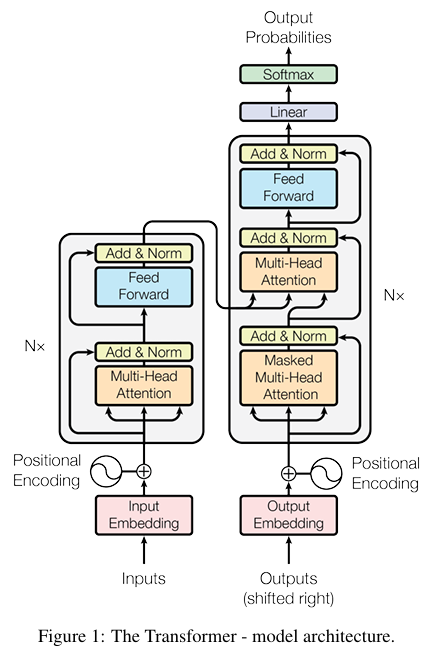
---



## Detailed Explanation

### Why Transformers?

Traditional RNNs process sequences one token at a time.

Example:

```text
I → love → learning → transformers
```

Each word waits for the previous word.

Problems:

* Slow training
* Difficult long-range dependencies
* Limited parallelization

Transformers solve these issues using attention mechanisms.



---

### Self Attention

Each token looks at every other token.

Sentence:

```text
The animal didn't cross the street because it was tired.
```

The model learns:

```text
it → animal
```

through attention weights.

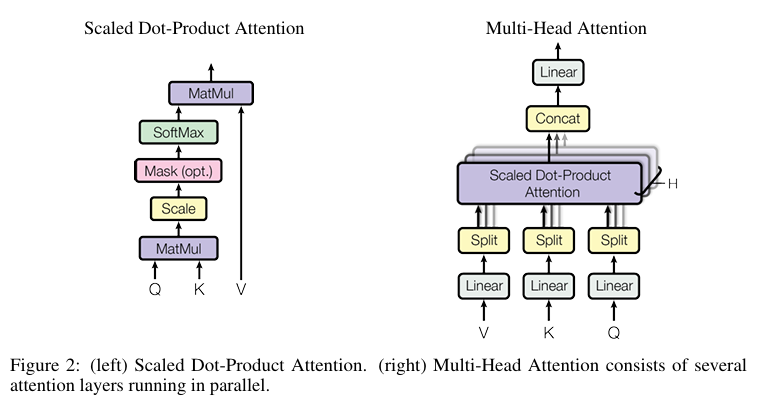
---

### Cross Attention

Used in encoder-decoder models.

Example:

```text
English:
I love AI

French:
J'aime l'IA
```

Decoder attends to encoder outputs.

---

### Masked Attention

Prevents future token leakage.

Example:

```text
I love ______
```

Prediction must not see future words.

Used in GPT.

---

### Positional Encoding

Transformers have no natural notion of order.

Positional encoding injects position information.

Example:

```text
Word  Position

I      1
love   2
AI     3
```

Sinusoidal encoding:

$$
PE(pos,2i) = sin\left(\frac{pos}{10000^{2i/d}}\right)
$$

$$
PE(pos,2i+1) = cos\left(\frac{pos}{10000^{2i/d}}\right)
$$

---

## Worked Example

Sentence:

```text
Machine Learning is powerful
```

Assume:

```text
Q = [1,0]
K = [1,1]
V = [2,3]
```

### Similarity

$$
QK^T = 1(1)+0(1) = 1
$$

### Scaling

$$
\frac{1}{\sqrt2} = 0.707
$$

### Softmax

$$
softmax(0.707) = 1
$$

### Output

$$
1 \times [2,3] = [2,3]
$$

Final attention output:

```text
[2,3]
```

---

## Python Demonstration

### Basic Self-Attention

In [3]:
import numpy as np

Q = np.array([[1, 0]])
K = np.array([[1, 1]])
V = np.array([[2, 3]])

scores = Q @ K.T

scaled_scores = scores / np.sqrt(K.shape[1])

weights = np.exp(scaled_scores)
weights = weights / weights.sum()

output = weights @ V

print(output)

[[2. 3.]]


---

### Hugging Face Example

In [4]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-uncased"
)

text = "Transformers changed NLP"

tokens = tokenizer(text)

print(tokens)

{'input_ids': [101, 19081, 2904, 17953, 2361, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1]}


## Industry Perspective

### Applications

#### ChatGPT

Uses:

* Decoder-only Transformer
* Masked Attention
* Autoregressive generation

#### BERT

Uses:

* Encoder-only Transformer
* Bidirectional attention

Applications:

* Search
* Classification
* Information Retrieval

#### T5

Uses:

* Encoder-Decoder architecture

Applications:

* Translation
* Summarization
* Question Answering

---

## Interview Questions

### Conceptual

1. Why are Transformers faster than RNNs?

2. What is Self-Attention?

3. Difference between Self-Attention and Cross-Attention?

4. Why is scaling performed in attention?

5. Why do we need Positional Encoding?

6. Why use Multi-Head Attention?

---

### Mathematical

1. Derive attention formula.

2. Explain softmax.

3. Compute attention output manually.

4. Why divide by √dk?

---

### Practical

1. GPT uses which attention?

2. BERT uses which attention?

3. Which architecture is used in machine translation?

4. Why is Transformer training expensive?

---

## Summary

### Key Takeaways

* Transformers replaced RNNs for most NLP tasks.
* Attention is the core building block.
* Self-Attention captures token relationships.
* Cross-Attention connects encoder and decoder.
* Masked Attention enables autoregressive generation.
* Positional Encoding provides sequence order information.
* Multi-Head Attention improves representation learning.
* Transformers enable parallel training and large-scale learning.

---

### References

#### Research Papers

#### Attention Is All You Need (2017)

**Authors:** Ashish Vaswani et al.

**Paper:**  
https://arxiv.org/abs/1706.03762

```bibtex
@article{vaswani2017attention,
  title={Attention Is All You Need},
  author={Vaswani, Ashish and others},
  journal={Advances in Neural Information Processing Systems},
  year={2017}
}
```

---

#### BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding (2018)

**Authors:** Jacob Devlin et al.

**Paper:**  
https://arxiv.org/abs/1810.04805

```bibtex
@article{devlin2018bert,
  title={BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding},
  author={Devlin, Jacob and Chang, Ming-Wei and Lee, Kenton and Toutanova, Kristina},
  year={2018}
}
```

---

#### GPT-3: Language Models are Few-Shot Learners (2020)

**Authors:** Tom B. Brown et al.

**Paper:**  
https://arxiv.org/abs/2005.14165

```bibtex
@article{brown2020gpt3,
  title={Language Models are Few-Shot Learners},
  author={Brown, Tom B. and others},
  journal={Advances in Neural Information Processing Systems},
  year={2020}
}
```

---

#### T5: Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer (2020)

**Authors:** Colin Raffel et al.

**Paper:**  
https://arxiv.org/abs/1910.10683

```bibtex
@article{raffel2020t5,
  title={Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer},
  author={Raffel, Colin and others},
  year={2020}
}
```

---

#### SentencePiece: A Simple and Language Independent Subword Tokenizer (2018)

**Authors:** Taku Kudo and John Richardson

**Paper:**  
https://arxiv.org/abs/1808.06226

```bibtex
@article{kudo2018sentencepiece,
  title={SentencePiece: A Simple and Language Independent Subword Tokenizer and Detokenizer for Neural Text Processing},
  author={Kudo, Taku and Richardson, John},
  year={2018}
}
```

---

#### PaLM: Scaling Language Modeling with Pathways (2022)

**Authors:** Aakanksha Chowdhery et al.

**Paper:**  
https://arxiv.org/abs/2204.02311

```bibtex
@article{chowdhery2022palm,
  title={PaLM: Scaling Language Modeling with Pathways},
  author={Chowdhery, Aakanksha and others},
  year={2022}
}
```

---

#### Chinchilla: Training Compute-Optimal Large Language Models (2022)

**Authors:** Jordan Hoffmann et al.

**Paper:**  
https://arxiv.org/abs/2203.15556

```bibtex
@article{hoffmann2022chinchilla,
  title={Training Compute-Optimal Large Language Models},
  author={Hoffmann, Jordan and others},
  year={2022}
}
```

---

#### LoRA: Low-Rank Adaptation of Large Language Models (2021)

**Authors:** Edward J. Hu et al.

**Paper:**  
https://arxiv.org/abs/2106.09685

```bibtex
@article{hu2021lora,
  title={LoRA: Low-Rank Adaptation of Large Language Models},
  author={Hu, Edward J. and others},
  year={2021}
}
```

---

#### QLoRA: Efficient Finetuning of Quantized LLMs (2023)

**Authors:** Tim Dettmers et al.

**Paper:**  
https://arxiv.org/abs/2305.14314

```bibtex
@article{dettmers2023qlora,
  title={QLoRA: Efficient Finetuning of Quantized LLMs},
  author={Dettmers, Tim and others},
  year={2023}
}
```

---

#### Llama 3 Technical Report (2024)

**Authors:** Meta AI

**Paper:**  
https://arxiv.org/abs/2407.21783

```bibtex
@article{dubey2024llama3,
  title={The Llama 3 Herd of Models},
  author={Dubey, Abhimanyu and others},
  year={2024}
}
```

---

### Documentation

#### PyTorch

https://pytorch.org/docs/stable/

#### Hugging Face Transformers

https://huggingface.co/docs/transformers/

#### Hugging Face Datasets

https://huggingface.co/docs/datasets/

#### Hugging Face Evaluate

https://huggingface.co/docs/evaluate/

#### Jupyter Book

https://jupyterbook.org/

#### NumPy

https://numpy.org/doc/

#### Pandas

https://pandas.pydata.org/docs/

#### Scikit-Learn

https://scikit-learn.org/stable/

---

### Further Reading

#### Dive Into Deep Learning (D2L)

https://d2l.ai/

Recommended Chapters:

- Attention Mechanisms
- Transformers
- BERT
- Sequence Models

---

#### Stanford CS224N

Natural Language Processing with Deep Learning

https://web.stanford.edu/class/cs224n/

Recommended Lectures:

- Word Embeddings
- Attention
- Transformers
- Pretrained Language Models
- Large Language Models

---

#### The Illustrated Transformer

https://jalammar.github.io/illustrated-transformer/

---

#### The Illustrated GPT-2

https://jalammar.github.io/illustrated-gpt2/

---

#### Hugging Face NLP Course

https://huggingface.co/learn/nlp-course/

---

#### Full Stack Deep Learning

https://fullstackdeeplearning.com/

---

### Citation Style

When citing in notes, use:

[Vaswani et al., 2017]

[Brown et al., 2020]

[Devlin et al., 2018]

[Hoffmann et al., 2022]

[Raffel et al., 2020]

Example:

> The Transformer architecture introduced self-attention as the primary mechanism for sequence modeling [Vaswani et al., 2017].

> GPT-3 demonstrated strong few-shot learning capabilities at scale [Brown et al., 2020].

> Chinchilla showed that compute-optimal training requires balancing model parameters and training tokens [Hoffmann et al., 2022].